# World Bank Analysis

In [43]:
import pandas as pd
import psycopg2

# Connect to RDS 

conn = psycopg2.connect(
    host="worldbank-db.c8hyu8gkak7d.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="postgres",
    password="Georgetown2026!",
    sslmode="require"
)

df = pd.read_sql("SELECT * FROM worldbank_panel", conn)
df.head()

C:\Users\Samantha\AppData\Local\Temp\ipykernel_25228\3288937361.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM worldbank_panel", conn)


,country_code,country_name,year,internet_users_pct,gdp_per_capita,life_expectancy,secondary_enrollment_pct,ingested_at
0,ABW,Aruba,2000,15.442823,20681.023027,72.939,91.580200,2026-04-16T16:11:51.246302+00:00
1,ABW,Aruba,2001,17.100000,20740.132583,73.044,97.556534,2026-04-16T16:11:51.246302+00:00
2,ABW,Aruba,2002,18.800000,21307.248251,73.135,100.163063,2026-04-16T16:11:51.246302+00:00
3,ABW,Aruba,2003,20.800000,21949.485996,73.236,101.929070,2026-04-16T16:11:51.246302+00:00
4,ABW,Aruba,2004,23.000000,23700.631990,73.223,100.940941,2026-04-16T16:11:51.246302+00:00


In [44]:
df.info

<bound method DataFrame.info of      country_code country_name  year  internet_users_pct  gdp_per_capita  \
0             ABW        Aruba  2000           15.442823    20681.023027   
1             ABW        Aruba  2001           17.100000    20740.132583   
2             ABW        Aruba  2002           18.800000    21307.248251   
3             ABW        Aruba  2003           20.800000    21949.485996   
4             ABW        Aruba  2004           23.000000    23700.631990   
...           ...          ...   ...                 ...             ...   
6259          ZWE     Zimbabwe  2019           26.588301     2184.329239   
6260          ZWE     Zimbabwe  2020           29.298565     2059.674454   
6261          ZWE     Zimbabwe  2021           32.592400     2613.605421   
6262          ZWE     Zimbabwe  2022           36.256500     2536.400502   
6263          ZWE     Zimbabwe  2023           38.674801     2195.224921   

      life_expectancy  secondary_enrollment_pct  \
0   

In [45]:
df.describe()

,year,internet_users_pct,gdp_per_capita,life_expectancy,secondary_enrollment_pct
count,6264.000000,5259.000000,6097.000000,6264.000000,4486.000000
mean,2011.500000,38.141707,14782.204004,70.521526,79.823513
std,6.922739,31.147768,23376.875545,8.596453,28.074701
min,2000.000000,0.000000,109.593814,14.665000,3.347850
25%,2005.750000,8.100000,1555.493758,65.232000,61.205086
50%,2011.500000,31.500000,5030.134947,71.967427,86.522602
75%,2017.250000,66.492306,18465.541442,76.894280,99.743328
max,2023.000000,100.000000,256799.788613,86.372000,164.079819


In [46]:
import pandas as pd

df = df.dropna(subset=[
    'internet_users_pct',
    'gdp_per_capita',
    'life_expectancy',
    'secondary_enrollment_pct'
]).copy()

# Log GDP
import numpy as np
df['log_gdp_pc'] = np.log(df['gdp_per_capita'])

In [60]:
# Correlation analysis

corr = df[[
    'internet_users_pct',
    'log_gdp_pc',
    'life_expectancy',
    'secondary_enrollment_pct'
]].corr()

print(corr)

                          internet_users_pct  log_gdp_pc  life_expectancy  \
internet_users_pct                  1.000000    0.801474         0.721193   
log_gdp_pc                          0.801474    1.000000         0.829911   
life_expectancy                     0.721193    0.829911         1.000000   
secondary_enrollment_pct            0.709088    0.799366         0.810868   

                          secondary_enrollment_pct  
internet_users_pct                        0.709088  
log_gdp_pc                                0.799366  
life_expectancy                           0.810868  
secondary_enrollment_pct                  1.000000  


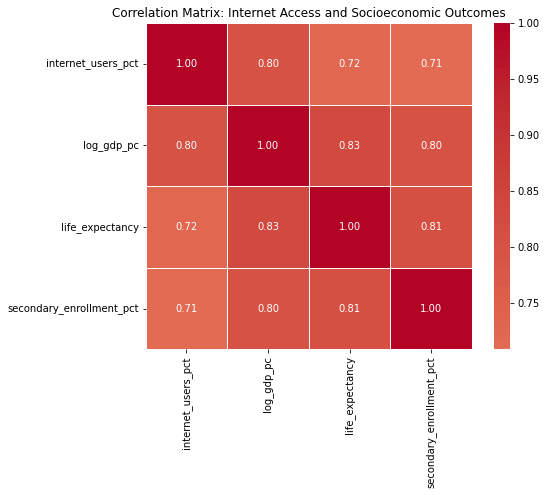

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    'internet_users_pct',
    'log_gdp_pc',
    'life_expectancy',
    'secondary_enrollment_pct'
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix: Internet Access and Socioeconomic Outcomes")
plt.show()

## **Internet access is strongly associated with broader development outcomes, but likely reflects underlying economic capacity (GDP)** 

Internet access is strongly and positively correlated with income, education, and health outcomes. Countries with higher internet penetration tend to have higher GDP per capita, higher secondary enrollment, and higher life expectancy. The correlations are substantial across all dimensions, particularly between internet access and GDP per capita (0.80), and between GDP and life expectancy (0.83), suggesting that internet access is closely embedded within broader development processes rather than operating in isolation.

Importantly, these patterns indicate that economic development is a key underlying driver of both human capital outcomes and connectivity. As countries become wealthier, they are simultaneously able to invest in infrastructure (including internet access), education systems, and health systems. This creates a strong risk of omitted variable bias. Without controlling for GDP per capita, the estimated relationship between internet access and education or health outcomes would likely be overstated.

The central empirical question is therefore not whether internet access is correlated with better outcomes, which it clearly is, but whether it has an independent effect on human capital once income and baseline development conditions are controlled for.

In [70]:
# Baseline regressions

import statsmodels.api as sm

X = df[['internet_users_pct', 'log_gdp_pc']]
X = sm.add_constant(X)

y = df['secondary_enrollment_pct']

model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     secondary_enrollment_pct   R-squared:                       0.652
Model:                                  OLS   Adj. R-squared:                  0.652
Method:                       Least Squares   F-statistic:                     3581.
Date:                      Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                              23:07:15   Log-Likelihood:                -16182.
No. Observations:                      3824   AIC:                         3.237e+04
Df Residuals:                          3821   BIC:                         3.239e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

## **A 1 percentage point increase in internet access is associated with a 0.17 percentage point increase in enrollment. Internet access has a positive but secondary independent effect on education once GDP is accounted for.**

When controlling for GDP per capita, both internet access and economic development remain statistically significant predictors of secondary enrollment, but their relative magnitudes differ substantially. A one unit increase in log GDP per capita is associated with approximately a 12 percentage point increase in secondary enrollment, indicating that economic development is the dominant predictor of educational attainment in this specification.

Importantly, these estimates should be interpreted as pooled cross-country associations that do not fully account for global time trends or country-specific fixed effects. As a result, they likely reflect a combination of structural differences across countries and shared patterns of global development over time. Including time controls in further specifications reduces the magnitude of the internet coefficient, but does not eliminate its positive association with education outcomes.

This does not imply that internet access is irrelevant. Rather, its effect appears to be conditional on broader development conditions. The results suggest that digital connectivity alone is unlikely to generate large improvements in education outcomes without complementary economic and institutional foundations.

In [73]:
# Key model with interaction term and year fixed effects

df['internet_x_gdp'] = df['internet_users_pct'] * df['log_gdp_pc']

year_dummies = pd.get_dummies(df['year'], drop_first=True).astype(float)

X = pd.concat([
    df[['internet_users_pct', 'log_gdp_pc', 'internet_x_gdp']].astype(float),
    year_dummies
], axis=1)

X = sm.add_constant(X)

y = df['secondary_enrollment_pct'].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     secondary_enrollment_pct   R-squared:                       0.699
Model:                                  OLS   Adj. R-squared:                  0.697
Method:                       Least Squares   F-statistic:                     339.6
Date:                      Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                              23:11:33   Log-Likelihood:                -15903.
No. Observations:                      3824   AIC:                         3.186e+04
Df Residuals:                          3797   BIC:                         3.203e+04
Df Model:                                26                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

## **Holding GDP and time constant, countries with higher internet access have substantially higher secondary enrollment rates.**

This model introduces an interaction between internet access and GDP per capita, allowing the effect of internet penetration to vary with a country’s level of economic development. The results show that internet access, GDP per capita, and their interaction term are all statistically significant predictors of secondary enrollment.

The positive coefficient on internet access (1.58) indicates that, holding GDP and year fixed effects constant, higher levels of internet penetration are associated with substantially higher secondary enrollment rates. However, the negative interaction term (-0.130) implies that the marginal effect of internet access decreases as GDP increases. In other words, internet access has its strongest association with educational outcomes in lower-income contexts, but its incremental contribution diminishes as countries become wealthier.

The effect is nonlinear and reflects diminishing marginal returns to connectivity that vary  with economic development. 

In [76]:
# Within-country model

df = df.sort_values(['country_code','year'])

df['internet_change'] = df.groupby('country_code')['internet_users_pct'].diff()
df['life_exp_change'] = df.groupby('country_code')['life_expectancy'].diff()

df_diff = df.dropna().copy()

df_diff['year'] = df.loc[df_diff.index, 'year']

# ensure numeric types
df_diff['internet_change'] = pd.to_numeric(df_diff['internet_change'], errors='raise')
df_diff['life_exp_change'] = pd.to_numeric(df_diff['life_exp_change'], errors='raise')
df_diff['year'] = pd.to_numeric(df_diff['year'], errors='raise')

year_dummies = pd.get_dummies(df_diff['year'], drop_first=True).astype(float)

X = pd.concat([
    df_diff[['internet_change']].astype(float),
    year_dummies
], axis=1)

X = sm.add_constant(X)

y = df_diff['life_exp_change'].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_exp_change   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     23.11
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.43e-90
Time:                        23:19:12   Log-Likelihood:                -5424.7
No. Observations:                3602   AIC:                         1.090e+04
Df Residuals:                    3578   BIC:                         1.105e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2608      0.116     

## **A one percentage point increase in internet penetration is associated with a 0.027 year increase in life expectancy within the same period, holding constant common global shocks.**

This specification examines within-country changes over time by regressing changes in life expectancy on changes in internet access, while also controlling for global year fixed effects. The coefficient on internet change is positive and statistically significant (0.0265). A meaningful portion of variation in life expectancy changes is driven by global time-specific factors, including major worldwide health and development shocks. The significance of the internet coefficient suggests that even after accounting for these shared temporal trends, increases in digital connectivity are associated with small but systematic improvements in health outcomes.

In [78]:
# Nonlinear pattern check - quadratic

df = df.copy()

df['internet_users_pct'] = pd.to_numeric(df['internet_users_pct'], errors='raise')
df['log_gdp_pc'] = pd.to_numeric(df['log_gdp_pc'], errors='raise')
df['secondary_enrollment_pct'] = pd.to_numeric(df['secondary_enrollment_pct'], errors='raise')

# quadratic term 
df['internet_sq'] = df['internet_users_pct'] ** 2

# year fixed
year_dummies = pd.get_dummies(df['year'], drop_first=True).astype(float)

X = pd.concat([
    df[['internet_users_pct', 'internet_sq', 'log_gdp_pc']].astype(float),
    year_dummies
], axis=1)


X = X.apply(pd.to_numeric, errors='raise')
X = sm.add_constant(X)

y = df['secondary_enrollment_pct'].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     secondary_enrollment_pct   R-squared:                       0.684
Model:                                  OLS   Adj. R-squared:                  0.682
Method:                       Least Squares   F-statistic:                     315.8
Date:                      Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                              23:24:56   Log-Likelihood:                -15999.
No. Observations:                      3824   AIC:                         3.205e+04
Df Residuals:                          3797   BIC:                         3.222e+04
Df Model:                                26                                         
Covariance Type:                  nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

## **Initial increases in internet penetration are associated with large gains in secondary enrollment, but the marginal effect declines steadily as access expands.** 

The relationship between internet access and secondary education is strongly nonlinear, with evidence of diminishing marginal returns as connectivity increases. The positive coefficient on internet access (0.90) and the statistically significant negative quadratic term (-0.0057) indicate a concave relationship.

Based on the estimated coefficients, the marginal effect of internet access approaches zero at relatively high levels of penetration (approximately the upper 60–70% range), suggesting that saturation occurs gradually rather than abruptly.

Controlling for GDP per capita and year fixed effects, the pattern remains clear, implying that this nonlinear relationship is not driven by cross-country income differences or global time trends. Economic development remains a strong predictor of educational outcomes, but internet access contributes independently in a way that is most impactful at lower/mid levels of connectivity.

The highest returns to digital infrastructure investments are likely in countries with moderate levels of internet penetration. Rather than focusing on a strict cutoff, the evidence supports targeting countries along the steep part of the curve—where increases in connectivity still translate into meaningful improvements in educational attainment.

## Clustering

In [79]:
# Remove time contamination

df_base = df.sort_values('year').groupby('country_code').first().reset_index()


# Construct features 

df_base['internet_sq'] = df_base['internet_users_pct'] ** 2
df_base['internet_gdp'] = df_base['internet_users_pct'] * df_base['log_gdp_pc']

# nonlinear “returns position” proxy
df_base['marginal_return_proxy'] = (
    0.9021 + 2 * (-0.0057) * df_base['internet_users_pct']
)

# investment-relevant gap variables (40-70% connectivity, high returns)
df_base['internet_midrange_distance'] = (
    df_base['internet_users_pct'] - 55
).abs()

In [80]:
# Scaling features 

features = df_base[[
    'internet_users_pct',
    'log_gdp_pc',
    'internet_sq',
    'internet_gdp',
    'marginal_return_proxy',
    'internet_midrange_distance'
]].dropna()

from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(features)

In [81]:
# K-means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_base['investment_cluster'] = kmeans.fit_predict(X)

In [85]:
# Examine resulting clusters 
cluster_summary = (
    df_base
    .groupby('investment_cluster')
    .agg(
        cluster_size=('country_code', 'count'),
        internet_users_pct=('internet_users_pct', 'mean'),
        log_gdp_pc=('log_gdp_pc', 'mean'),
        secondary_enrollment_pct=('secondary_enrollment_pct', 'mean'),
        life_expectancy=('life_expectancy', 'mean'),
        internet_gap_50=('internet_gap_50', 'mean')
    )
)

print(cluster_summary)

                    cluster_size  internet_users_pct  log_gdp_pc  \
investment_cluster                                                 
0                             53           17.238056    9.137304   
1                            140            2.350799    6.904373   
2                             25           47.760153   10.218718   
3                              4           88.920553   10.820206   

                    secondary_enrollment_pct  life_expectancy  internet_gap_50  
investment_cluster                                                              
0                                  93.430332        74.500100        32.761944  
1                                  51.248649        62.415643        47.649201  
2                                 102.326649        77.799301         4.725585  
3                                 117.522630        82.756823         0.000000  


### Cluster 0: Low connectivity, low income, early-stage development economies

This cluster represents countries with low internet penetration (17.2%) and moderate GDP per capita (log 9.14), along with relatively strong but uneven human capital outcomes, including high secondary enrollment (93.4) and life expectancy (74.5). Importantly, these countries have a substantial gap to the 50% connectivity benchmark (32.8), indicating meaningful room for expansion but also reflecting structural constraints that may limit immediate returns.

These economies are in an early-stage digital development phase where connectivity remains limited but not extremely constrained relative to the lowest income group. While human capital indicators are not as weak as in the poorest cluster, the combination of low connectivity and moderate development suggests that returns to internet expansion are likely positive but dependent on good institutional and infrastructure conditions. Investment in digital access here may yield benefits, but effects are likely slower to materialize than in mid-transition economies.

### Cluster 1: Very low connectivity, low income, structurally constrained economies 

This group is characterized by extremely low internet penetration (2.35%) and the lowest GDP per capita (log 6.90), alongside weak secondary enrollment (51.2) and low life expectancy (62.4). These countries are furthest from the 50% connectivity benchmark (gap 47.6), indicating severe infrastructural deficits and limited digital integration.

This cluster represents the most structurally constrained economies in the sample, where both digital infrastructure and broader development foundations are weak. In these settings, internet expansion alone is unlikely to generate large immediate gains in human capital outcomes, as foundational constraints in education systems, health infrastructure, and institutional capacity limit its capacity to absorb positive digital investment effects. 

### Cluster 2: Mid-income, high-connectivity, high-performing human capital systems

This cluster includes moderately high-income countries (log GDP 10.22) with relatively high internet penetration (47.8%), strong secondary enrollment (102.3), and high life expectancy (77.8). These countries are very close to the 50% connectivity benchmark (gap 4.7), indicating that they are approaching or operating near the nonlinear transition region identified in the regression analysis.

These economies represent advanced transition systems where digital infrastructure is already relatively well-developed and integrated into education and health systems. The high human capital outcomes suggest strong absorptive capacity, and internet access is likely still associated with meaningful gains, but marginal returns are beginning to flatten. These countries are approaching saturation in the connectivity/education relationship, consistent with diminishing returns observed in the quadratic model.

### Cluster 3: High income, near-saturation, advanced digital economies

This cluster represents the most developed group, with very high internet penetration (88.9%), the highest GDP per capita (log 10.82), and the strongest human capital outcomes in the sample, including the highest secondary enrollment (117.5) and life expectancy (82.8). These countries are fully saturated in terms of connectivity, as reflected by a zero internet gap to the 50% benchmark.

In these contexts, internet infrastructure is already mature and deeply embedded in economic and social systems. Additional investments in basic connectivity are unlikely to yield meaningful marginal improvements in education or health outcomes due to strong diminishing returns. Policy focus in these countries would more appropriately shift toward advanced digital transformation, productivity enhancement, and innovation rather than expansion of access.

## **Investment Target: Cluster 0**

- Moderate income levels relative to low connectivity
- Strong but not fully leveraged human capital systems
- Large connectivity gap with potential for catch-up growth
- Positioned in early part of nonlinear curve where returns remain positive but conditional

## **Secondary Target: Cluster 2** 

- High human capital systems already in place
- Near the nonlinear transition region (~50% penetration)
 Still some room for gains, but diminishing returns emerging
- Best suited for targeted, efficiency-focused digital investments

In [89]:
# Cluster 0 countries top investment candidates (lowest connectivity, within viable development range)

top_targets = df_base[df_base['investment_cluster'] == 0].sort_values(
    by='marginal_return_proxy', ascending=False
)

print(top_targets[['country_code', 'internet_users_pct', 'marginal_return_proxy']].head(10))

    country_code  internet_users_pct  marginal_return_proxy
28           BRB            3.973678               0.856800
106          KNA            5.862810               0.835264
20           BHR            6.153733               0.831947
165          QAT            6.170269               0.831759
10           ATG            6.482226               0.828203
108          KWT            6.731396               0.825362
8            ARG            7.038683               0.821859
190          SYC            7.395629               0.817790
50           DMA            8.814844               0.801611
29           BRN            8.996285               0.799542


In [90]:
conn.close()
print("Connection closed.")

Connection closed.
